In [ ]:
pip install pillow


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


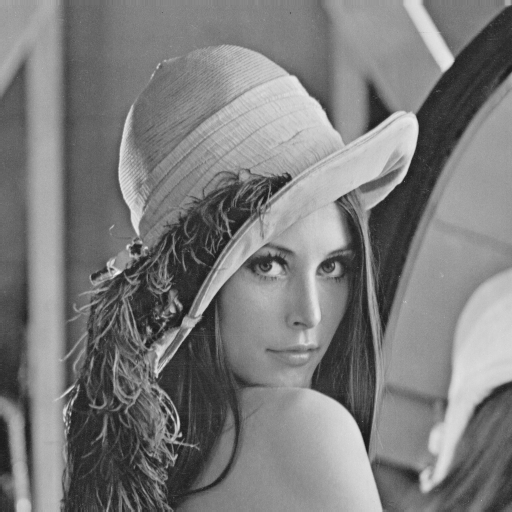

In [3]:
from PIL import Image
image = Image.open("/content/drive/MyDrive/AI and ML/Data/lena_gray.gif")
display(image)

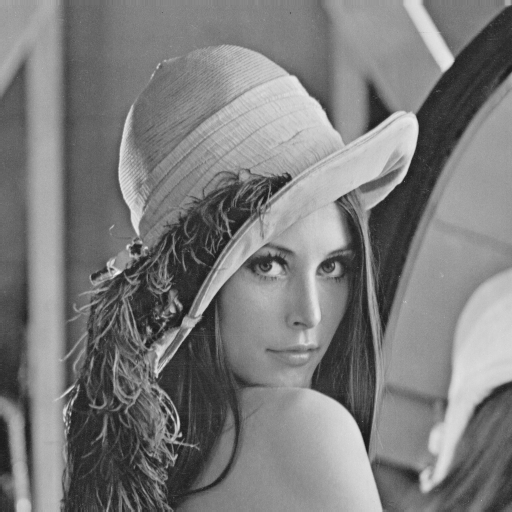

In [4]:
image

In [5]:
print ("Image format :" ,image.format)
print ("Image size : ", image.size)
print ("image mode: ", image.mode)

Image format : GIF
Image size :  (512, 512)
image mode:  P


In [6]:
width, height = image.size
channels = len(image.getbands())
print ( f" Image shape (RGB): ({ height } , { width } , { channels})")
image_colored = width*height*3
print ( f" Image size (RGB): { image_colored }")

 Image shape (RGB): (512 , 512 , 1)
 Image size (RGB): 786432


In [7]:
import numpy as np
image_array_colored = np.array(image)
print ("array of colored image: ", image_array_colored)


array of colored image:  [[116 116 116 ... 112  11 133]
 [116 116 116 ... 112  11 133]
 [116 116 116 ... 112  11 133]
 ...
 [ 77  77 177 ... 145 147 148]
 [183 183  65 ... 145  36 143]
 [183 183  65 ... 145  36 143]]


In [8]:

print ("Shape of array of colored image: ", image_array_colored.shape)

Shape of array of colored image:  (512, 512)


[[116 116 116 ... 112  11 133]
 [116 116 116 ... 112  11 133]
 [116 116 116 ... 112  11 133]
 ...
 [ 77  77 177 ... 145 147 148]
 [183 183  65 ... 145  36 143]
 [183 183  65 ... 145  36 143]]


array([[116, 116, 116, ..., 112,  11, 133],
       [116, 116, 116, ..., 112,  11, 133],
       [116, 116, 116, ..., 112,  11, 133],
       ...,
       [ 77,  77, 177, ..., 145, 147, 148],
       [183, 183,  65, ..., 145,  36, 143],
       [183, 183,  65, ..., 145,  36, 143]], dtype=uint8)
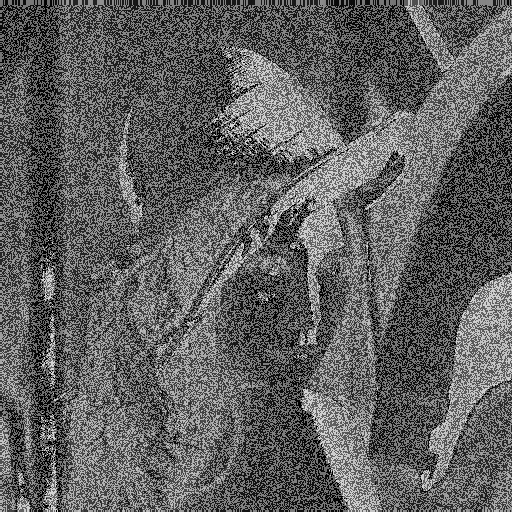

In [9]:
red_channel = image_array_colored[:,:]
print(red_channel)
display(red_channel)

[[116 116 116 ... 112  11 133]
 [116 116 116 ... 112  11 133]
 [116 116 116 ... 112  11 133]
 ...
 [ 77  77 177 ... 145 147 148]
 [183 183  65 ... 145  36 143]
 [183 183  65 ... 145  36 143]]


array([[116, 116, 116, ..., 112,  11, 133],
       [116, 116, 116, ..., 112,  11, 133],
       [116, 116, 116, ..., 112,  11, 133],
       ...,
       [ 77,  77, 177, ..., 145, 147, 148],
       [183, 183,  65, ..., 145,  36, 143],
       [183, 183,  65, ..., 145,  36, 143]], dtype=uint8)
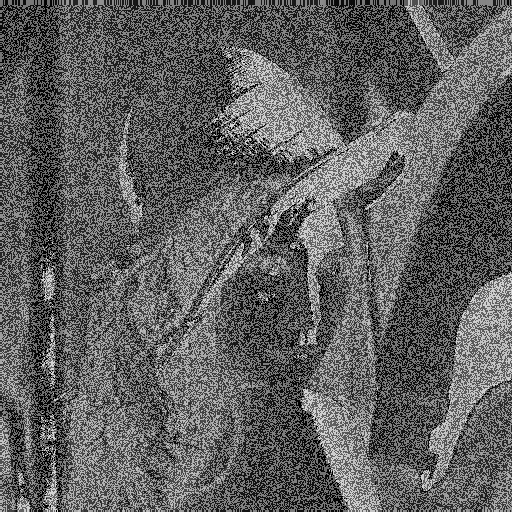

In [10]:
green_channel = image_array_colored[:,:]
print(green_channel)
display(green_channel)

[[116 116 116 ... 112  11 133]
 [116 116 116 ... 112  11 133]
 [116 116 116 ... 112  11 133]
 ...
 [ 77  77 177 ... 145 147 148]
 [183 183  65 ... 145  36 143]
 [183 183  65 ... 145  36 143]]


array([[116, 116, 116, ..., 112,  11, 133],
       [116, 116, 116, ..., 112,  11, 133],
       [116, 116, 116, ..., 112,  11, 133],
       ...,
       [ 77,  77, 177, ..., 145, 147, 148],
       [183, 183,  65, ..., 145,  36, 143],
       [183, 183,  65, ..., 145,  36, 143]], dtype=uint8)
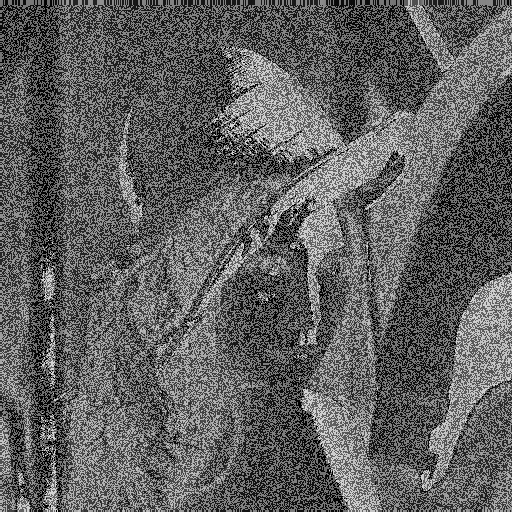

In [11]:
blue_channel = image_array_colored[:,:]
print(blue_channel)
display(blue_channel)

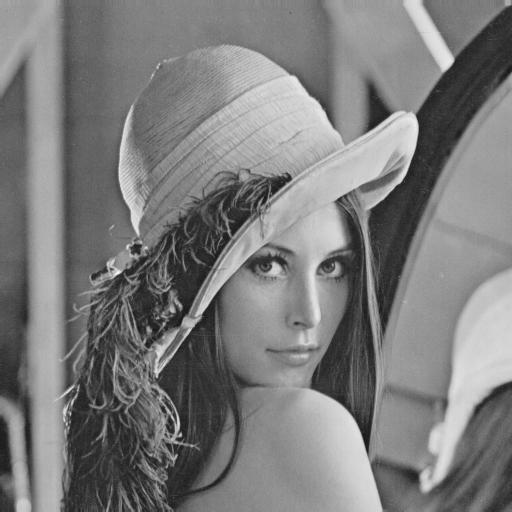

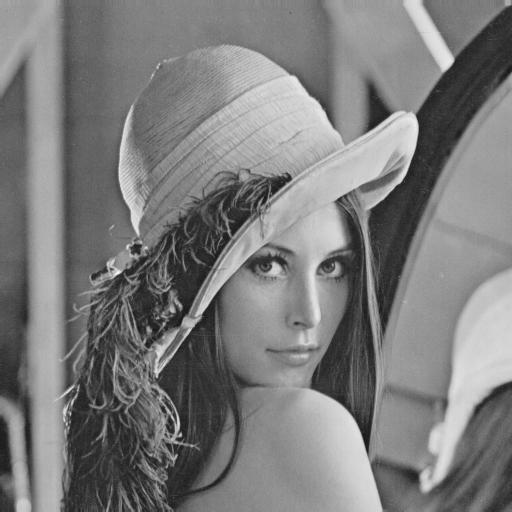

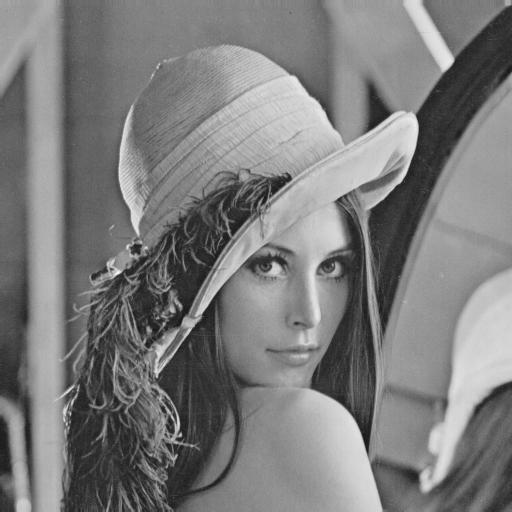

In [12]:
#Accessing individual channel
image_rgb = image.convert('RGB') # Convert to RGB first
r, g, b = image_rgb.split()
display(r)
display(g)
display(b)

In [13]:
row_100 = image_array_colored[100, :]
col_50 = image_array_colored[:, 50]
pixel = image_array_colored[100, 50]

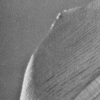

In [14]:
left = 100
upper = 50
right = 200
lower = 150
cropped_image = image.crop((left, upper, right, lower))
display(cropped_image)

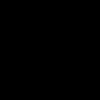

In [15]:
image_array = np.zeros((100, 100, 3), dtype=np.uint8)
image_from_array = Image.fromarray(image_array)
# image_from_array.show() # '.show()' can cause issues in environments like Colab, so it's commented out.
image_from_array.save ("output_image.jpg")
display(image_from_array)

PCA

In [39]:
import numpy as np
import matplotlib . pyplot as plt
from PIL import Image
# Load image and convert to grayscale
image = Image . open ("/content/drive/MyDrive/AI and ML/Data/cameraman.png") . convert ("L")
# Convert to NumPy array
image_array = np . array ( image )
# Get image dimensions
height , width = image_array . shape
# Reshape the image into a 2D array where each row represents a row of pixels
# This allows PCA to process each row as an observation andfind patterns across pixel intensities
data = image_array . reshape ( height , width )

In [40]:
# Compute the mean of each column ( feature )
mean = np . mean ( data , axis =0)

In [41]:
centered_data = data - mean

In [42]:

# Compute covariance matrix
cov_matrix = np . cov ( centered_data , rowvar = False )

In [43]:
# Compute eigenvalues and eigenvectors
eigenvalues , eigenvectors = np . linalg . eigh ( cov_matrix )
# Sort eigenvalues and corresponding eigenvectors in descending order
sorted_indices = np . argsort ( eigenvalues ) [:: -1]
eigenvalues = eigenvalues [ sorted_indices ]
eigenvectors = eigenvectors [: , sorted_indices ]

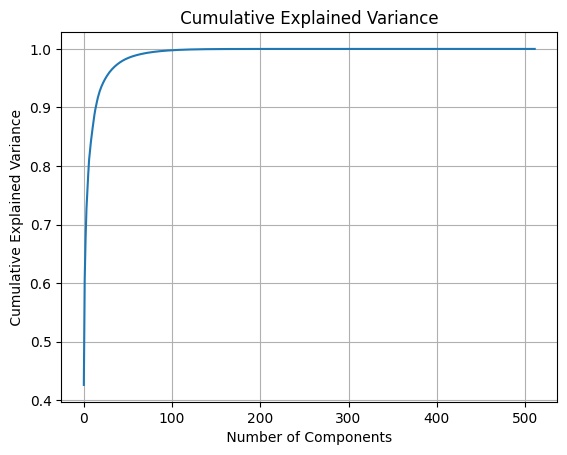

In [44]:
import matplotlib.pyplot as plt

# Plot the explained variance ratio
explained_variance_ratio = eigenvalues / np .sum ( eigenvalues )
plt . plot ( np . cumsum ( explained_variance_ratio ) )
plt . title (" Cumulative Explained Variance ")
plt . xlabel (" Number of Components ")
plt . ylabel (" Cumulative Explained Variance ")
plt . grid ( True )
plt . show ()

In [45]:
k = 50 # Choose k principal components
components = eigenvectors [: , : k ]

In [46]:
#Compress the image
# Project the data onto the principal components
compressed_data = np . dot ( centered_data , components )

In [47]:
#Decompress the image
 # Reconstruct the image from compressed data
decompressed_data = np.dot ( compressed_data , components . T ) + mean

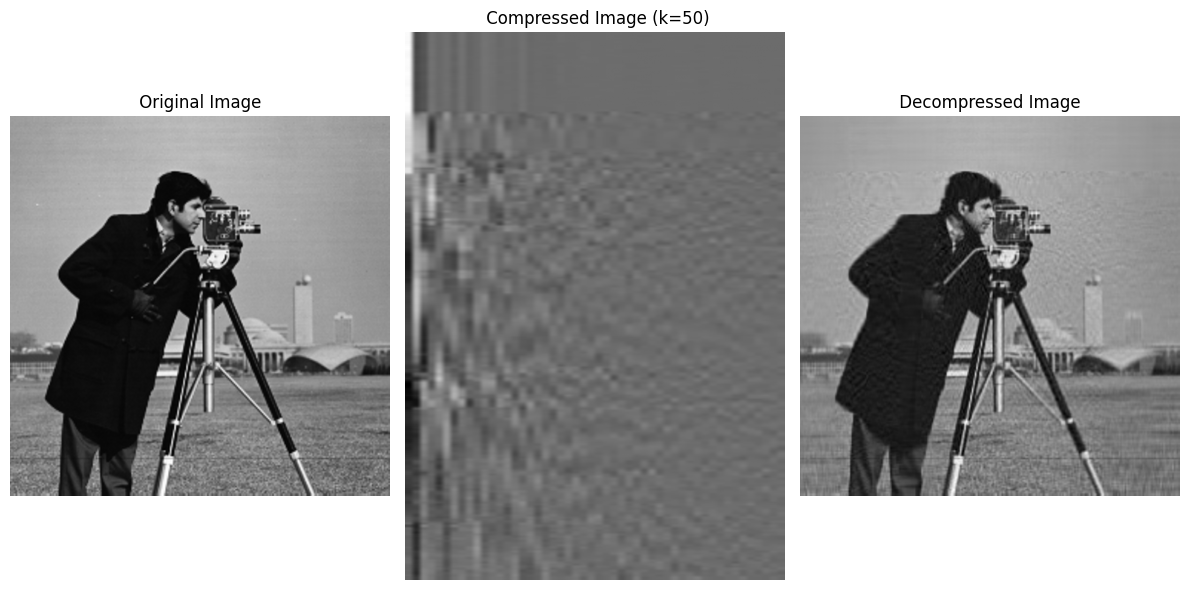

In [48]:
#Visualizing Original, Compressed & Reconstructed Images
plt . figure ( figsize =(12 , 6) )
# Original Image
plt . subplot (1 , 3 , 1)
plt . imshow ( image_array , cmap ="gray")
plt . title (" Original Image ")
plt . axis ("off")
 # Compressed Representation
plt . subplot (1 , 3 , 2)
plt . imshow ( compressed_data , cmap ="gray", aspect ="auto")
plt . title ( f" Compressed Image (k={k})")
plt . axis ("off")
# Decompressed Image
plt . subplot (1 , 3 , 3)
plt . imshow ( decompressed_data , cmap ="gray")
plt . title (" Decompressed Image ")
plt . axis ("off")
plt . tight_layout ()
plt . show ()